# Two photon analysis for Two_node_single_photon_experiment which is based on single_photon_experiment_3

Since 2026-06-24 until...

In [35]:
date_filters = ["2026-06-22", "2026-06-23", "2026-06-24"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints
import math

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan"], # only find files containing all these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=False
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-06-22\22\000037251-GeneralVariableScan.h5, which is corrupt
skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-06-24\15\000037290-GeneralVariableScan.h5, which is corrupt
found 80 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-06-22\08\000037182-GeneralVariableScan.h5) scanned over dummy_variable
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-06-22\08\000037182-GeneralVariableScan_atom_loading_2_scan_over_dummy_variable.h5) scanned over dummy_variable
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-06-22\08\000037183-GeneralVariableScan.h5) scanned over dummy_variable
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-06-22\08\000037183-GeneralVariableScan_microwave_Rabi_2_scan_over_dummy_variable.h5) scanned over dummy_variable
file 4 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-

experiment: Two_node_single_photon_2_experiment
override: {'t_delay_in_bob_mu': 189 ,  't_PGC_after_loading':0.6*ms, 'monitors_for_atom_loading':False,  't_recooling_after_first_shot':0*ms, 'n_excitation_attempts':1, 't_FORT_drop':0*us, 't_recooling':1*ms, 'atom_check_every_n':50, 'max_excitation_cycles':2000, 't_photon_collection_time':150*ns, 'gate_start_offset_mu':660}
# of iterations:  21
center=137.8000, sigma=571.5992, depth=0.9981


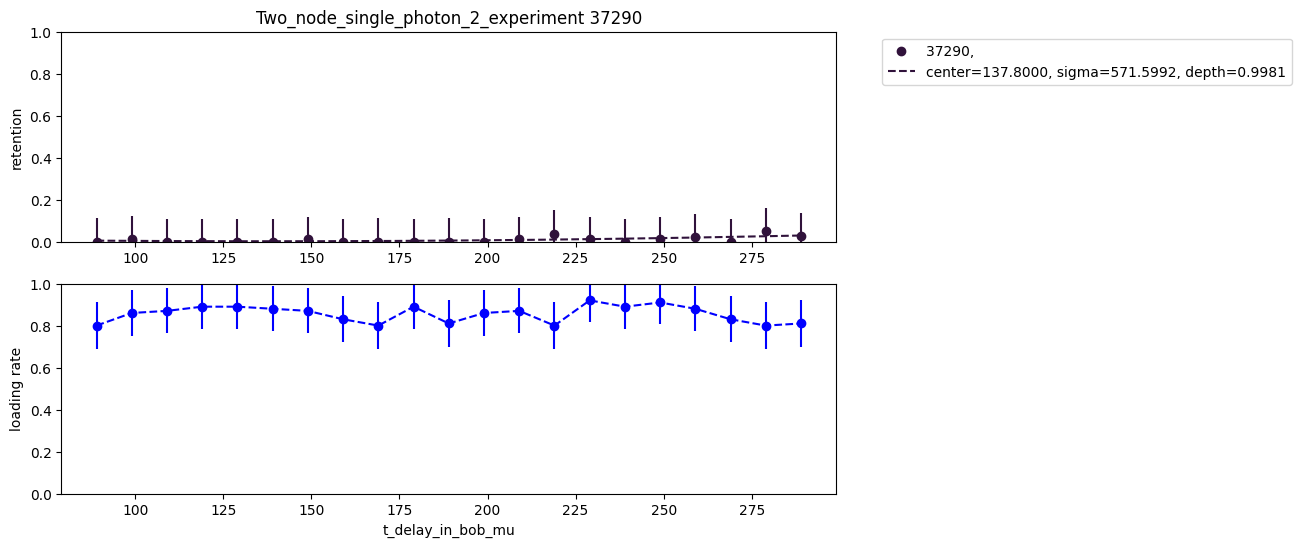

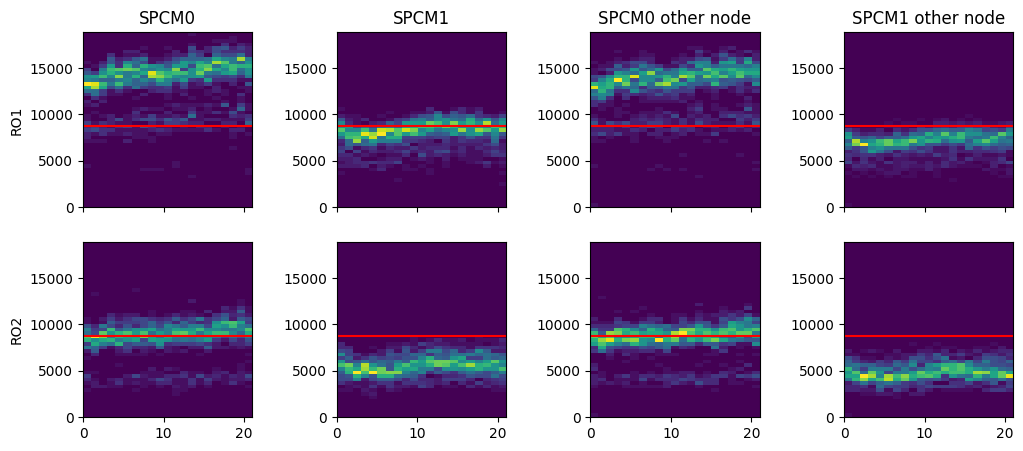

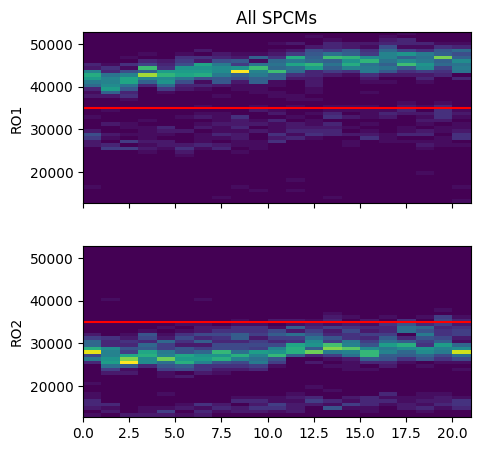

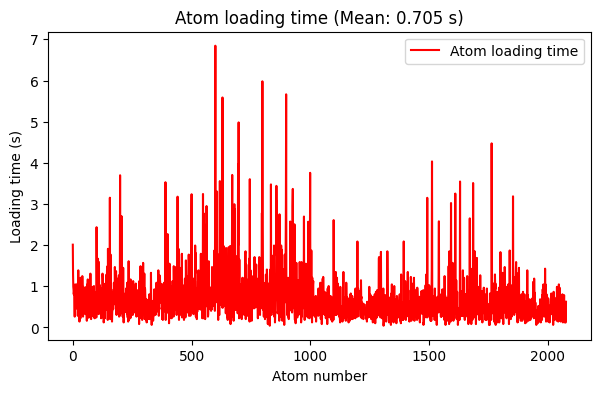

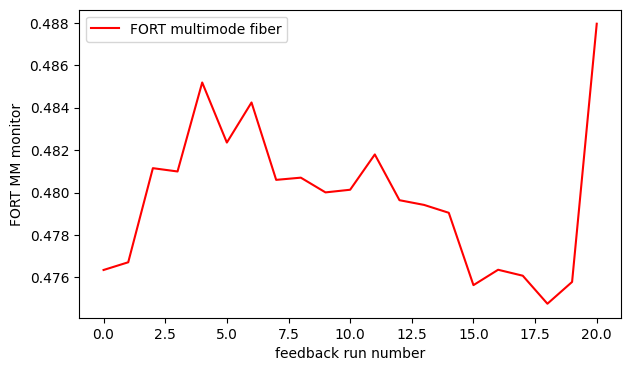

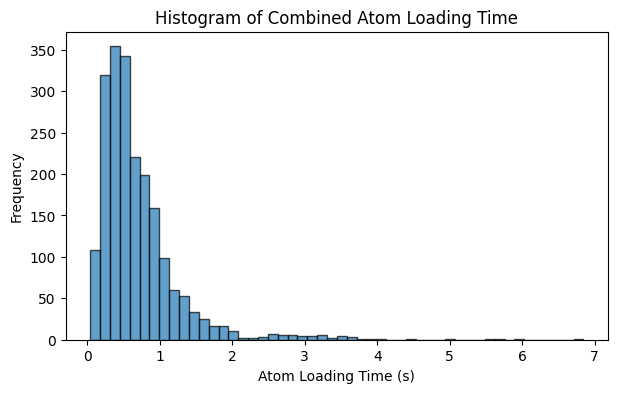

In [36]:
### the file(s) to analyze:
file_indices = {
    # 12:'',
    # 2:'',
    # 4:'',
    # 6:'',
    # 44:'',
    # 46:'',
    # 48:'',
    # 50:'',
    # 52:'',


    # 26:'',  # date_filters = ["2026-06-18"]

    #### Only in Alice
    # 46:'' #### 500 measurements; only alice
    # 48:''  #### 100 measurements test; both alice; but bob with excitation physically blocked
    # 50:''  #### 1000 measurements; but threshold is not good; 50%
    # 51:'' ####1000 measurements; threshold fixed
    # 53:'' #### 20 iterations; RID37252

    #### Only in Bob
    # 55:'' #### 10 iterations; RID37254

    # 56:''   #### test 1 iteration; 1us collection time
    # 60:''   #### 10 iterations; RID37263
    # 63:''  #### 10iterations; RID37267;; fixed timing for bob; t_delay_in_bob=180
    # 65:'' #### 5iterations; RID37268;; fixed timing for bob; t_delay_in_bob=186
    # 72:''   #### 5iterations; RID37268;; fixed timing for bob; t_delay_in_bob=189

    ####### HOM experiment
    # 73:'',   ##fine scan
    # 76:''   ##coarse scan np.arange(-100,101,10); crashed at ite=15; BaseExperiment underflow
    79:''  ##coarse scan np.arange(-100,101,10); fixed timing
} 

# file_indices = {i: '' for i in range(0, 17, 2)}

compare = True # compare multiple files in the same retention and loading plots
otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False
showhist = True
showloading = True
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = True

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=False, figsize=(10, 6))
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


SPCM0_RO1_hists = []
SPCM0_RO2_hists = []
SPCM1_RO1_hists = []
SPCM1_RO2_hists = []
SPCM0_OtherNode_RO1_hists = []
SPCM0_OtherNode_RO2_hists = []
SPCM1_OtherNode_RO1_hists = []
SPCM1_OtherNode_RO2_hists = []
BothSPCMs_RO1_hists = []
BothSPCMs_RO2_hists = []
AllSPCMs_RO1_hists = []
AllSPCMs_RO2_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''

all_atom_loading_times = []
all_atom_loading_wall_clocks = []

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)

    all_atom_loading_times.append(Atom_loading_time[1:])
    all_atom_loading_wall_clocks.append(atom_loading_wall_clock[1:])
    
    if otsu_threshold:
        # thresh = threshold_otsu(BothSPCMs_RO1)
        thresh = threshold_otsu(AllSPCMs_RO1)

        print("threshold_otsu: ", thresh)
    else:
        # cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot
        cutoff1 = cutoff2 = two_atom_threshold * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    # retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(BothSPCMs_RO1, BothSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(AllSPCMs_RO1, AllSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    # ### show historam of first_shot and second_shot
    # histMin = np.min([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    # histMax = np.max([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot


    ### Histogram boundaries for individual SPCMs
    single_hist_sources = [
        np.asarray(SPCM0_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM0_OtherNode_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_OtherNode_RO1) / t_SPCM_first_shot,
    
        np.asarray(SPCM0_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM0_OtherNode_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_OtherNode_RO2) / t_SPCM_second_shot,
    ]
    
    single_hist_sources = [x.ravel() for x in single_hist_sources if x.size > 0]
    
    histMin_single = min(np.min(x) for x in single_hist_sources)
    histMax_single = max(np.max(x) for x in single_hist_sources)
    
    
    ### Histogram boundaries for AllSPCMs
    all_hist_sources = [
        np.asarray(AllSPCMs_RO1) / t_SPCM_first_shot,
        np.asarray(AllSPCMs_RO2) / t_SPCM_second_shot,
    ]
    
    all_hist_sources = [x.ravel() for x in all_hist_sources if x.size > 0]
    
    histMin_all = min(np.min(x) for x in all_hist_sources)
    histMax_all = max(np.max(x) for x in all_hist_sources)


    
    if showhist:
        bins_single = np.linspace(histMin_single, histMax_single, 50)
        bins_all = np.linspace(histMin_all, histMax_all, 50)
    
        SPCM0_RO1_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_RO2_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO2_hists.append(
            [np.histogram(SPCM1_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO1_hists.append(
            [np.histogram(SPCM0_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO2_hists.append(
            [np.histogram(SPCM0_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO1_hists.append(
            [np.histogram(SPCM1_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO2_hists.append(
            [np.histogram(SPCM1_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO1_hists.append(
            [np.histogram(AllSPCMs_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO2_hists.append(
            [np.histogram(AllSPCMs_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=False)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            ### for fitting
            ### Auto-detect rough center from minimum retention
            fit_dict = {}
            min_idx = np.argmin(retention_array)
            initial_center = scan_sequence1[min_idx]
            p0 = [initial_center, 10e3, 0.9] # [center, width, depth]
            
            ### using a  Gaussian function for now:
            fit_dict = {
                scan_variable1_name: {
                    'model': lambda x, center, sigma, depth: 0.80*(1 - depth * np.exp(-((x - center)**2/(2*sigma**2)))),
                    'p0': p0,
                    'bounds': ([min(scan_sequence1), 0, 0], [max(scan_sequence1), np.inf, 1]),
                    'params': ['center', 'sigma', 'depth']
                }
            }

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    ### Individual SPCM plots
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 5), sharex=True)
    ax, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.ravel()

    ### RO1: SPCM0
    cax = ax.imshow(np.array(SPCM0_RO1_hists[0]).transpose(), origin='lower',
                    extent=[0, iterations, histMin_single, histMax_single])
    ax.set_ylabel("RO1")
    ax.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax.set_aspect('auto')
    ax.set_title("SPCM0")

    ### RO1: SPCM1
    cax2 = ax2.imshow(np.array(SPCM1_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax2.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax2.set_aspect('auto')
    ax2.set_title("SPCM1")

    ### RO1: SPCM0 Other Node
    cax3 = ax3.imshow(np.array(SPCM0_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax3.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax3.set_aspect('auto')
    ax3.set_title("SPCM0 other node")

    ### RO1: SPCM1 Other Node
    cax4 = ax4.imshow(np.array(SPCM1_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax4.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax4.set_aspect('auto')
    ax4.set_title("SPCM1 other node")


    ### RO2: SPCM0
    cax5 = ax5.imshow(np.array(SPCM0_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax5.set_ylabel("RO2")
    ax5.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax5.set_aspect('auto')

    ### RO2: SPCM1
    cax6 = ax6.imshow(np.array(SPCM1_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax6.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax6.set_aspect('auto')

    ### RO2: SPCM0 Other Node
    cax7 = ax7.imshow(np.array(SPCM0_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax7.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax7.set_aspect('auto')

    ### RO2: SPCM1 Other Node
    cax8 = ax8.imshow(np.array(SPCM1_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax8.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax8.set_aspect('auto')

    plt.subplots_adjust(hspace=0.2, wspace=0.5)


    ### All SPCMs plotted separately
    fig_all, axes_all = plt.subplots(nrows=2, ncols=1, figsize=(5, 5), sharex=True)
    ax_all1, ax_all2 = axes_all.ravel()

    ### RO1: All SPCMs
    cax_all1 = ax_all1.imshow(np.array(AllSPCMs_RO1_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all1.set_ylabel("RO1")
    ax_all1.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax_all1.set_aspect('auto')
    ax_all1.set_title("All SPCMs")

    ### RO2: All SPCMs
    cax_all2 = ax_all2.imshow(np.array(AllSPCMs_RO2_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all2.set_ylabel("RO2")
    ax_all2.axhline(cutoff2 / t_SPCM_second_shot, color='red')
    ax_all2.set_aspect('auto')

    plt.subplots_adjust(hspace=0.25)

plt.show()



#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = [t for loading_times in all_atom_loading_times for t in loading_times]
mean_loading_time = np.mean(combined_atom_loading_times)
plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_times, 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()


#### Plot FORT multimode fiber 
plt.figure(figsize=(7, 4))
plt.plot(FORT_MM_monitor, 'r-', label='FORT multimode fiber')
plt.xlabel("feedback run number")
plt.ylabel("FORT MM monitor")
# plt.title(f"FORT MM fiber")
plt.legend(loc='best')
plt.show()


# Plot the histogram of combined Atom_loading_time
plt.figure(figsize=(7, 4))
plt.hist(combined_atom_loading_times, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Atom Loading Time (s)")
plt.ylabel("Frequency")
plt.title(f"Histogram of Combined Atom Loading Time")
plt.show()



Early time stamp for 1 elements on SPCM0_OtherNode was detected.
Early time stamp for 1 elements on SPCM0_OtherNode was detected.
n_measurements = 100
excitation pulse width = 30.000000000000004 ns
SPCM window = 150.0 ns
excitation AOM power (dBm) = -5.0
n_excitation_attempts = 1
check atom avery n excitation cycles = 50
Overal photon detection efficiency (%) = 2.923076923076923


C:\Users\QC\AppData\Local\Temp\ipykernel_19660\3705547252.py:393: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 5, figsize=(18, 3), sharey=True, sharex=True)


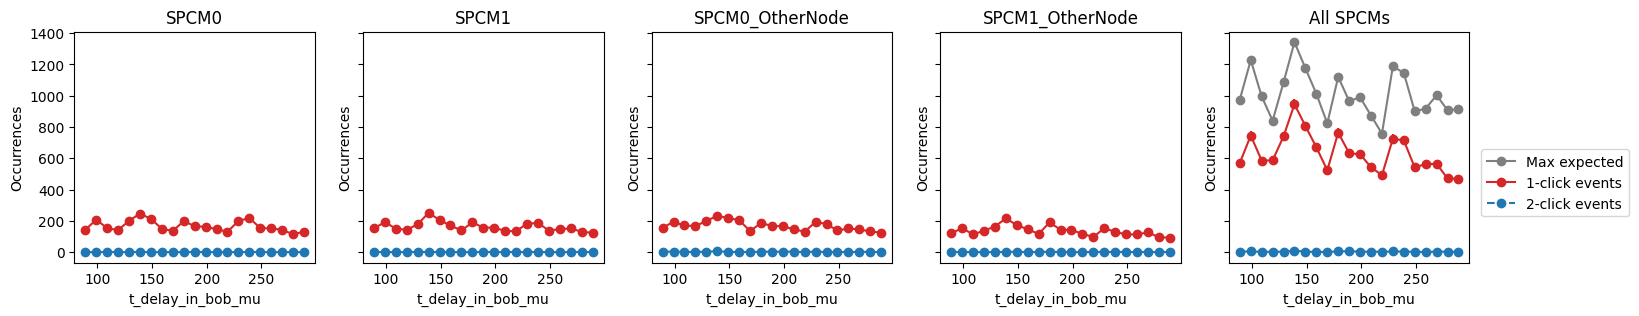

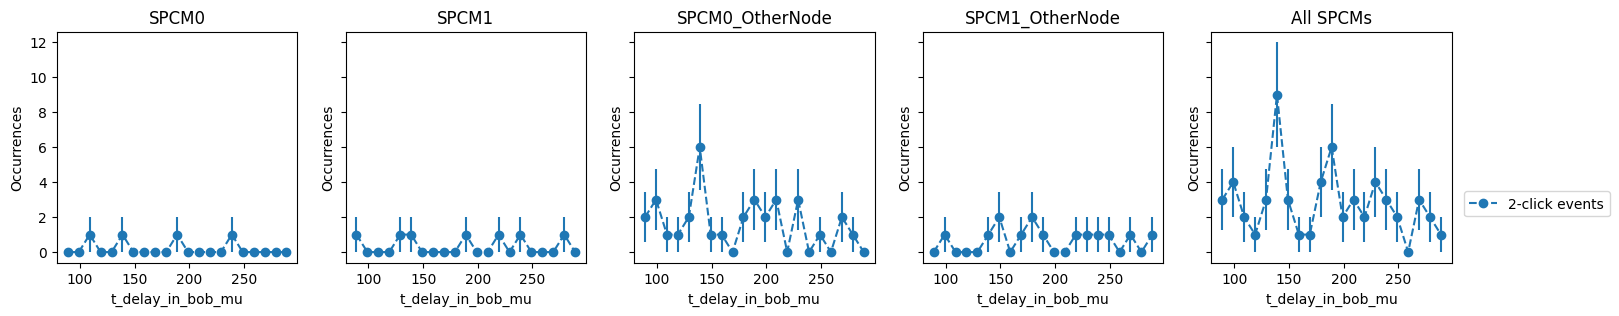

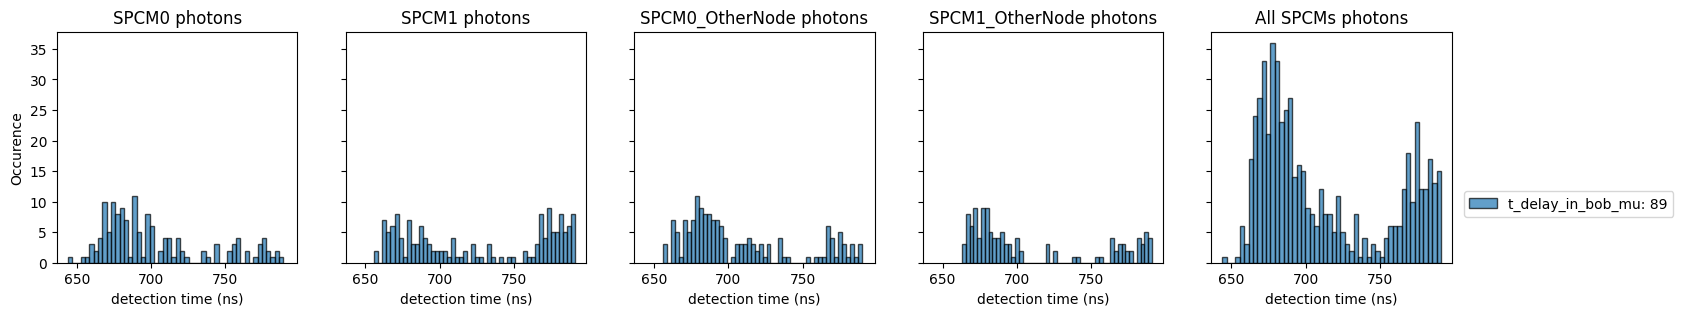

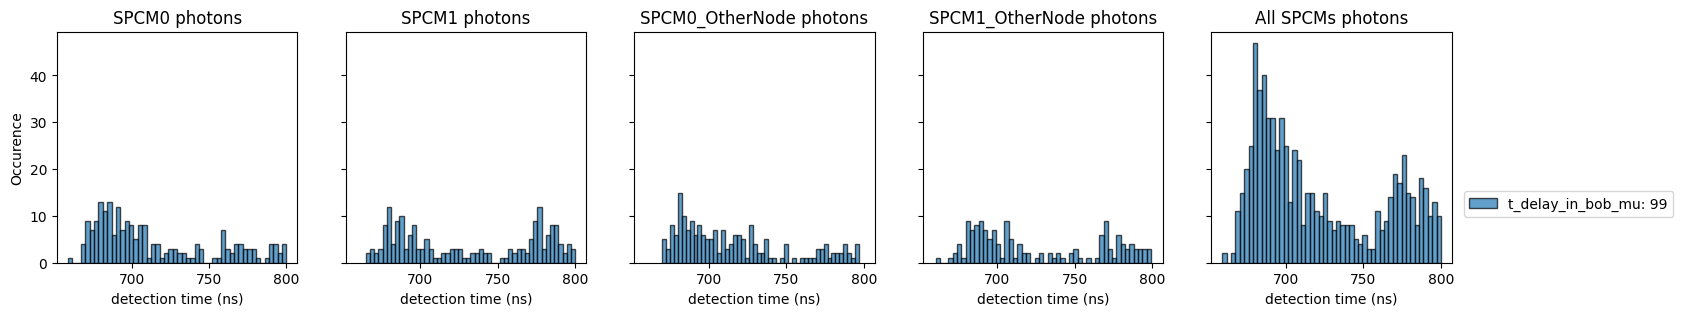

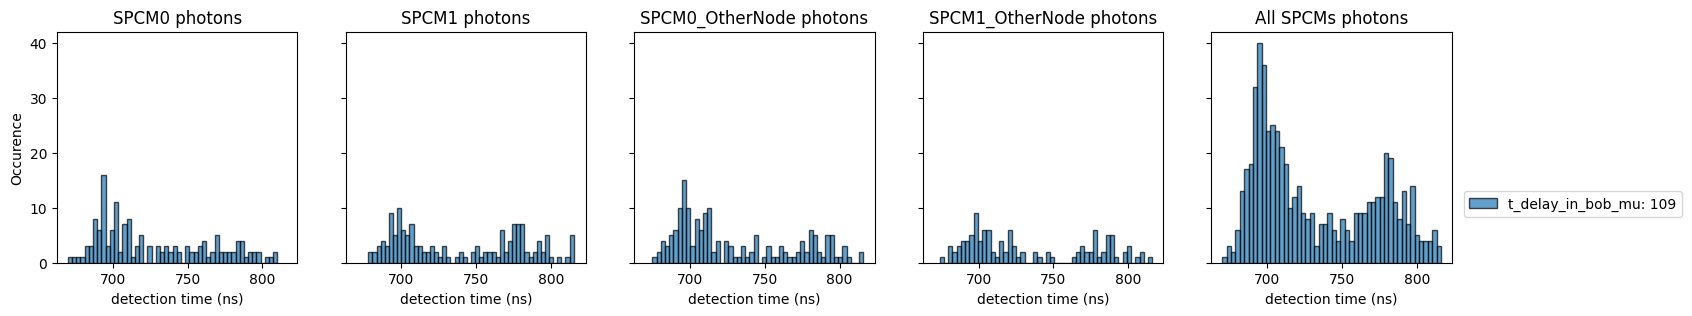

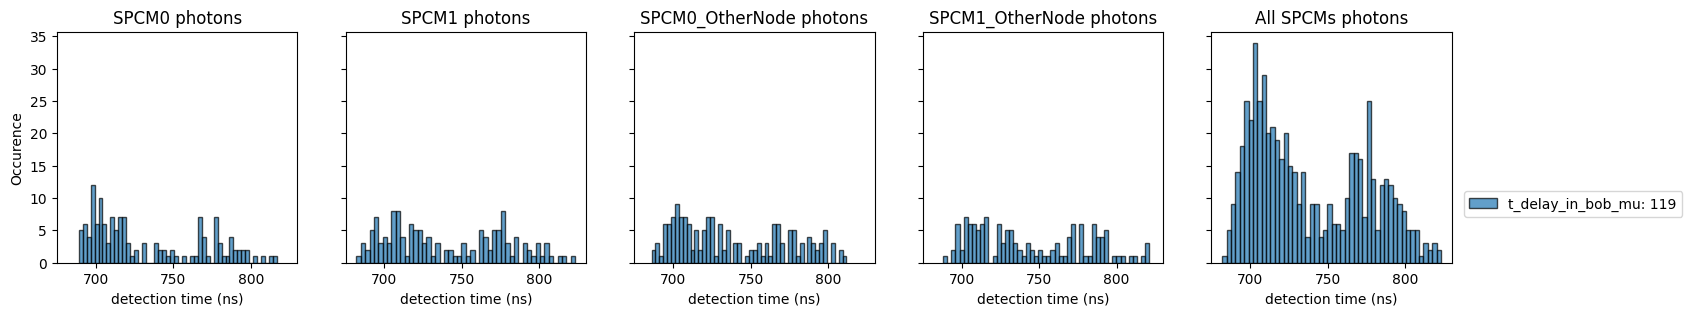

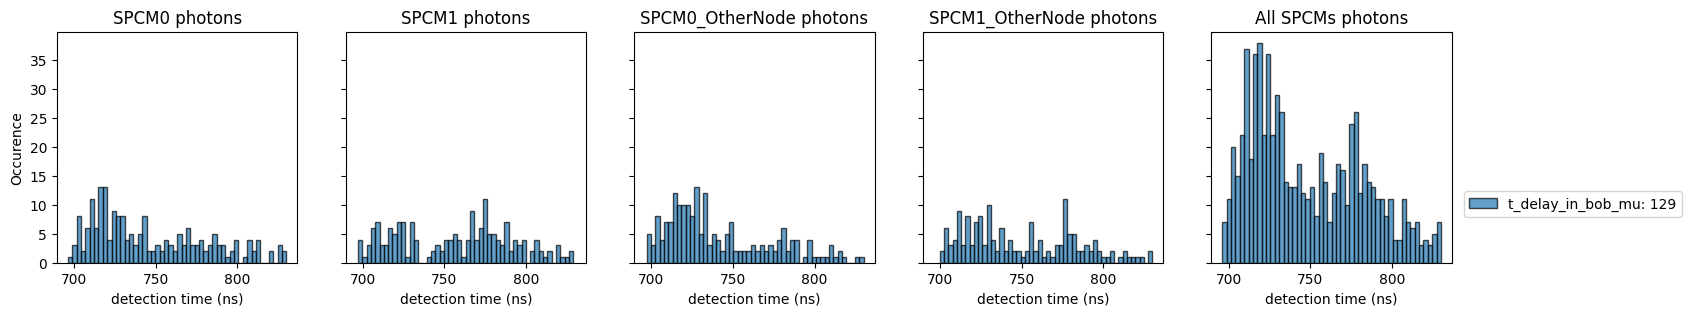

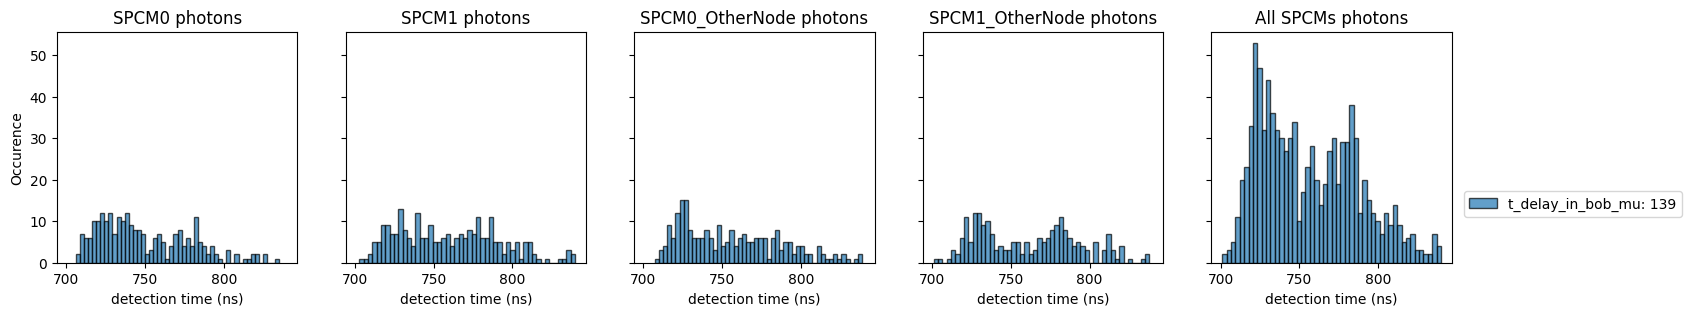

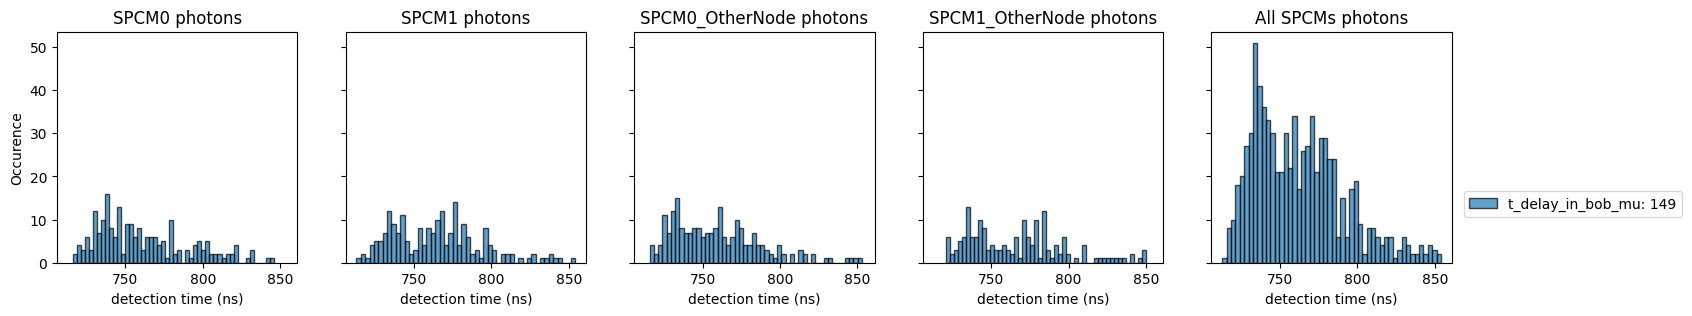

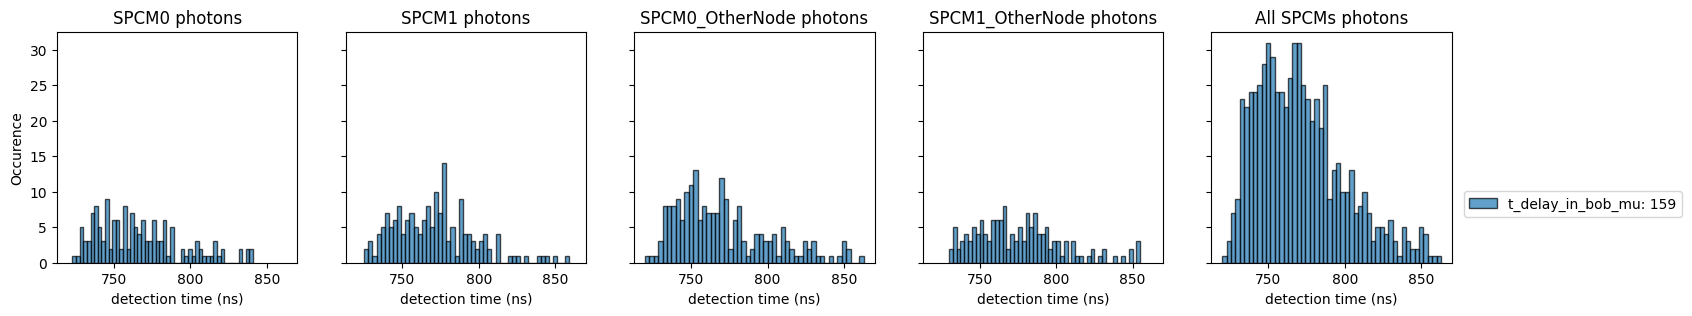

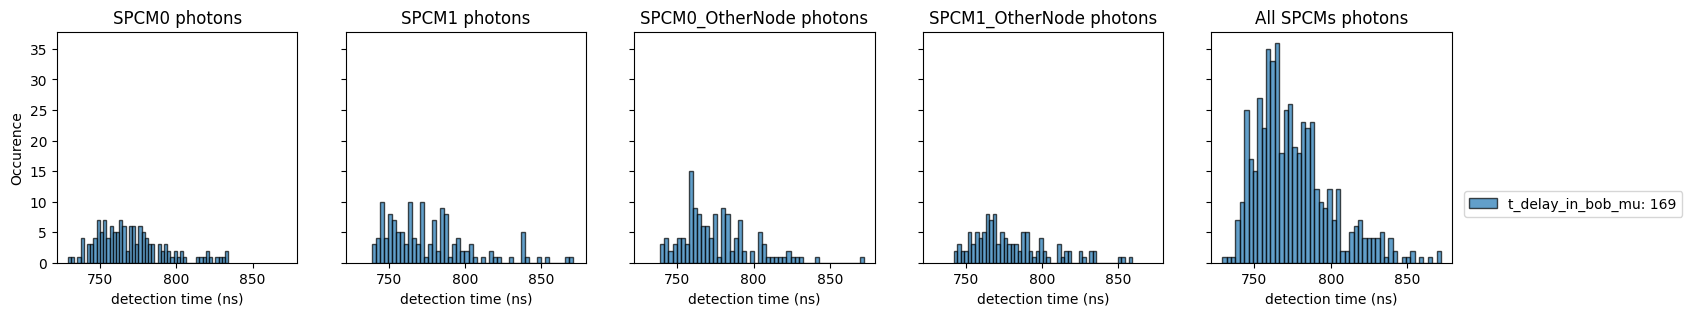

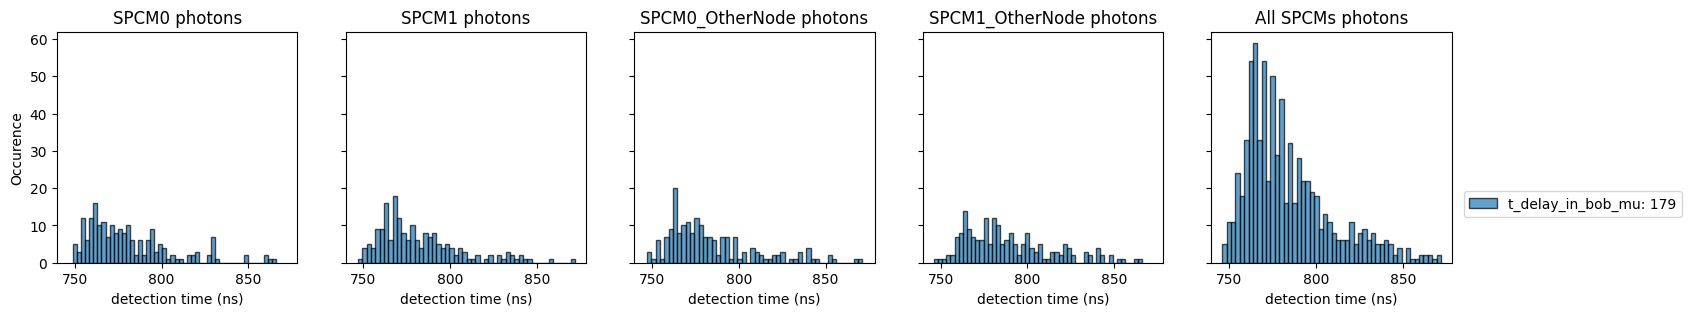

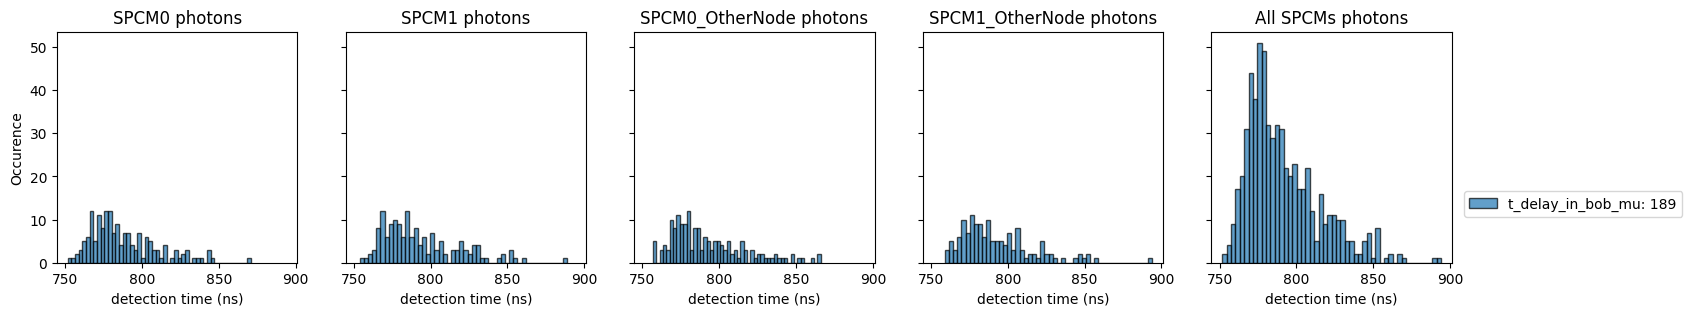

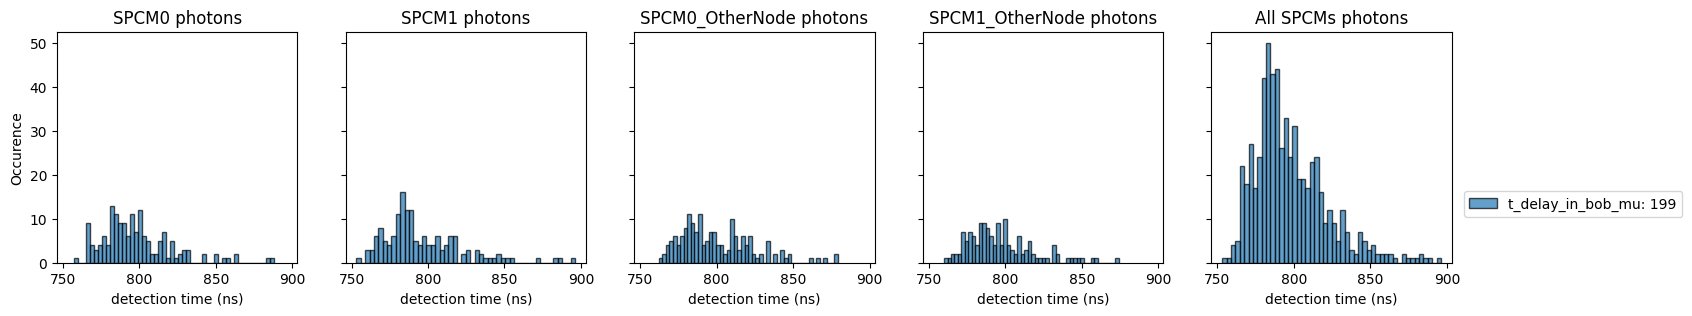

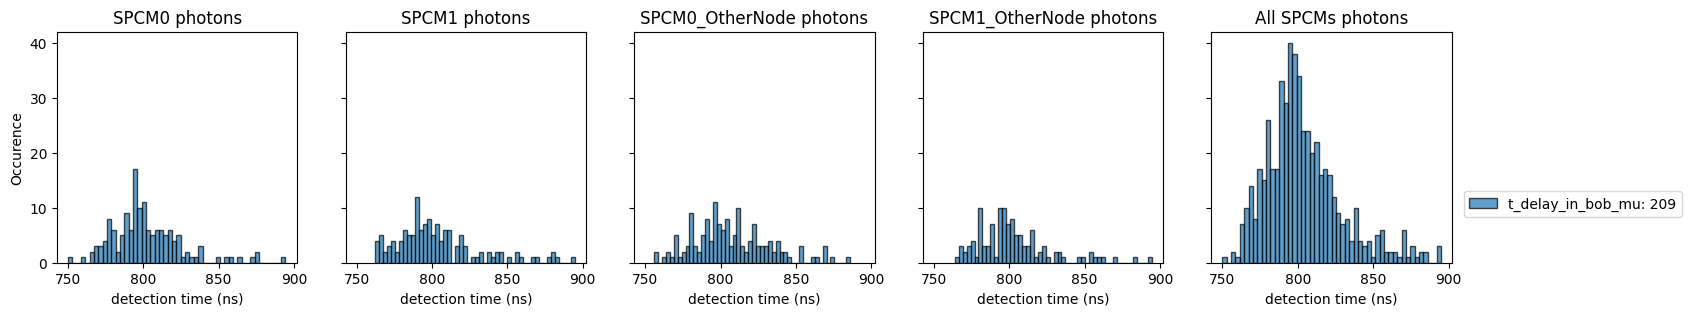

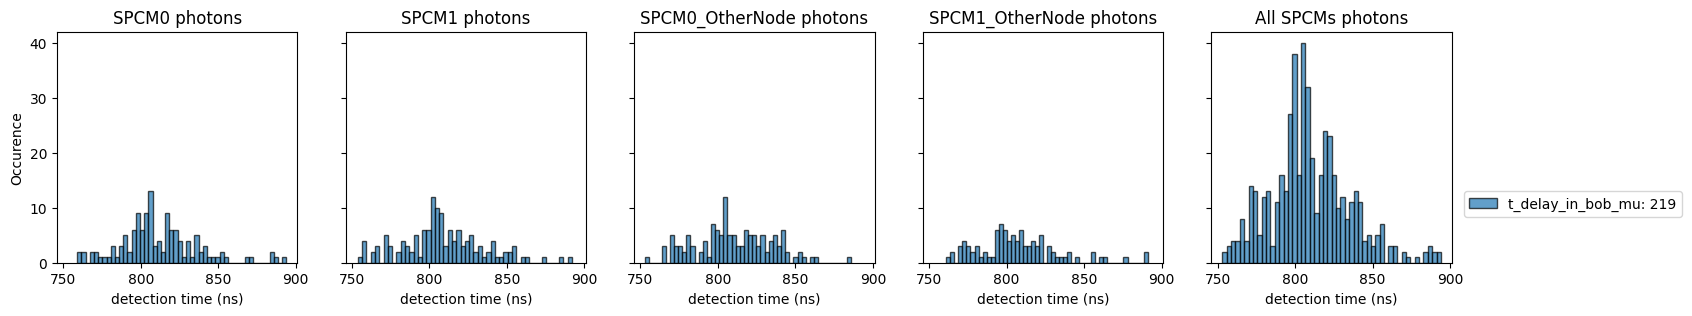

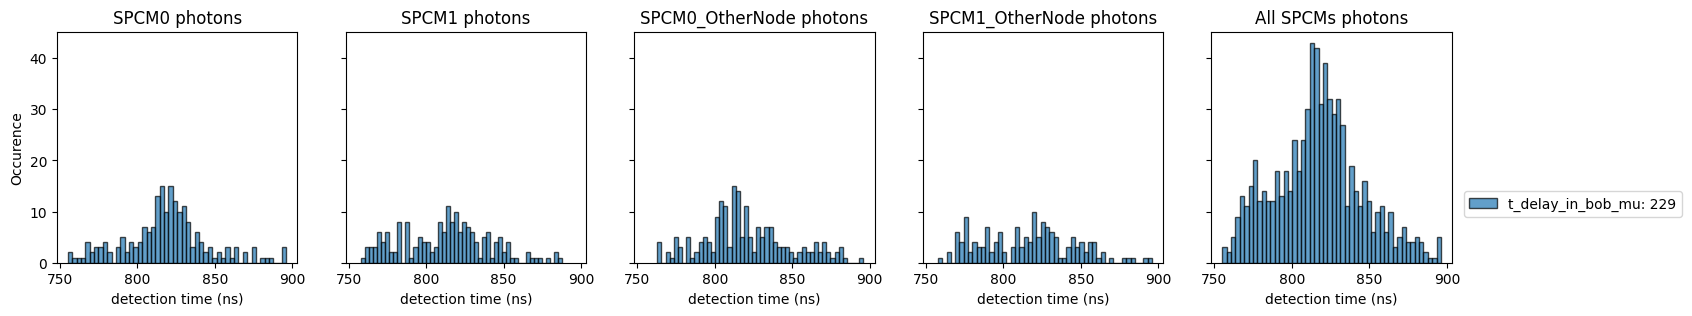

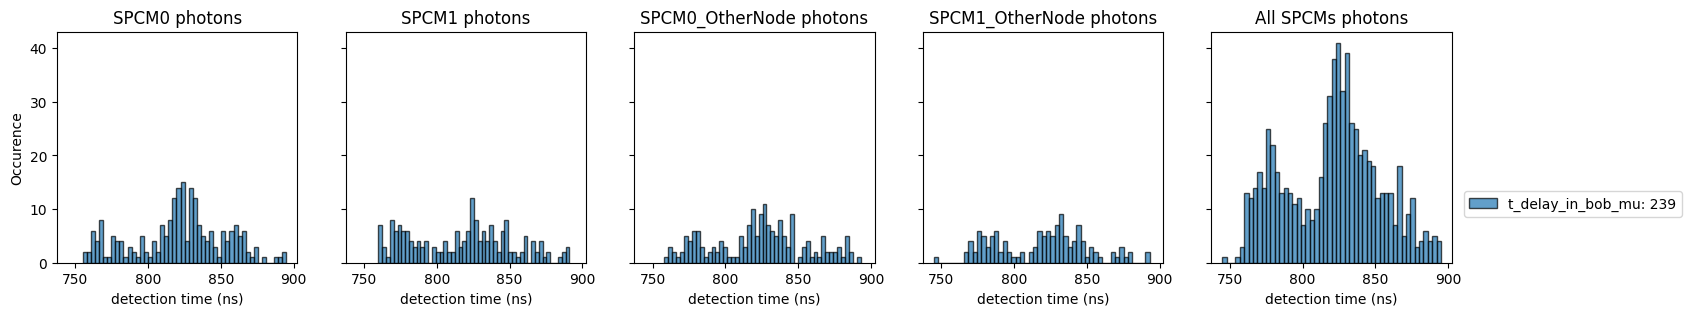

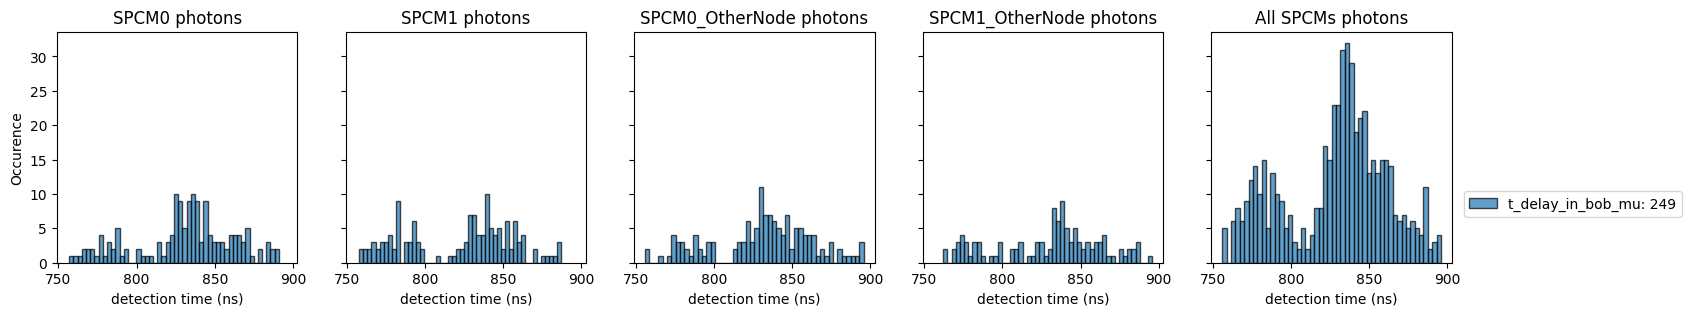

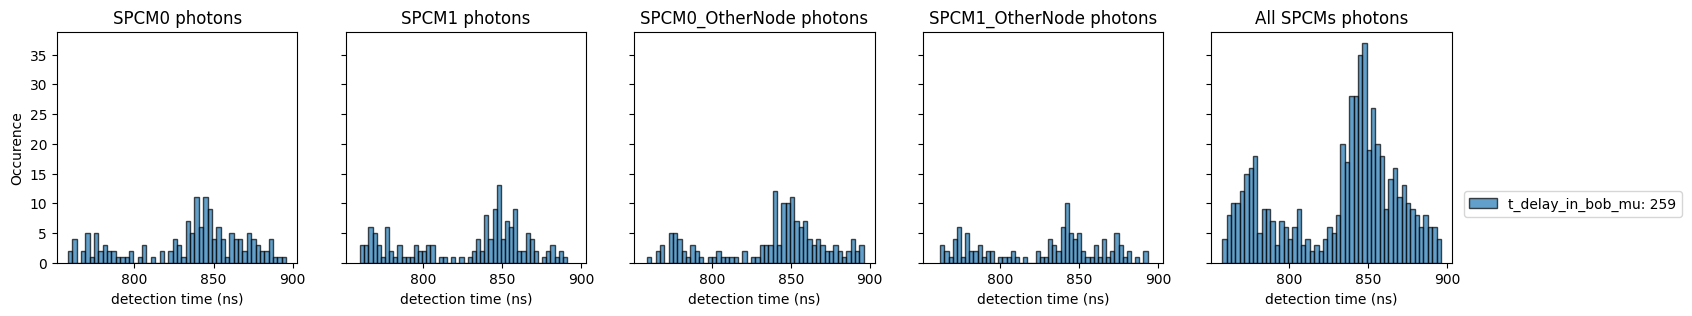

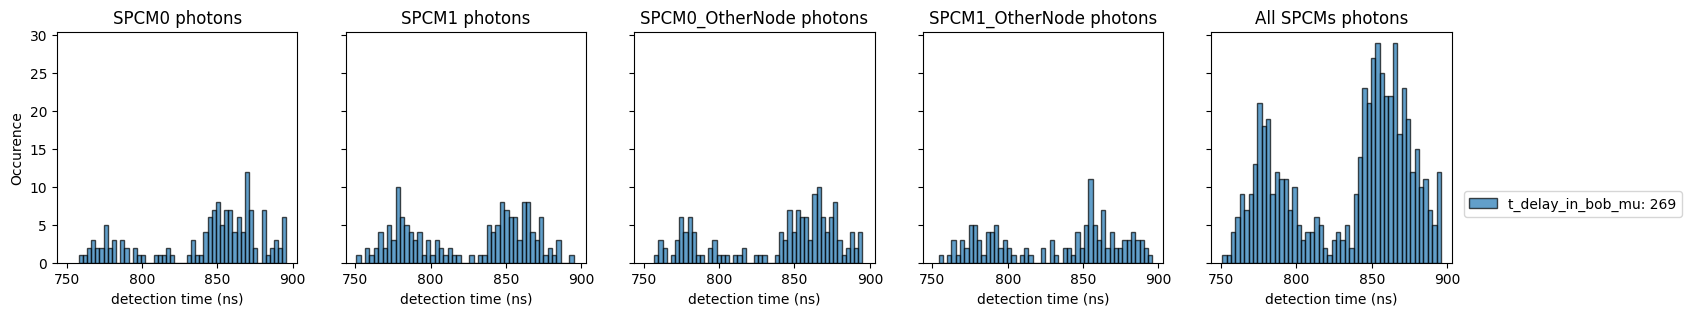

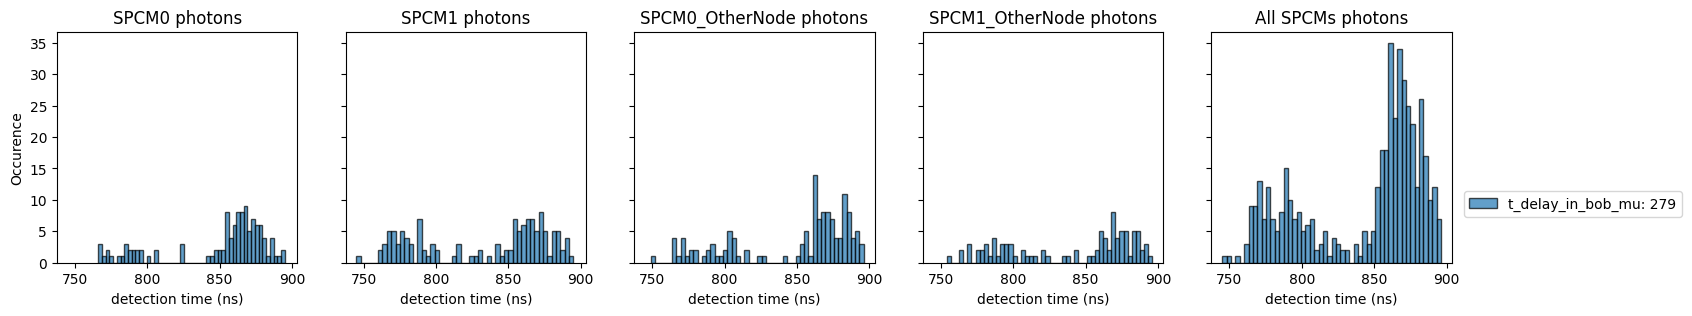

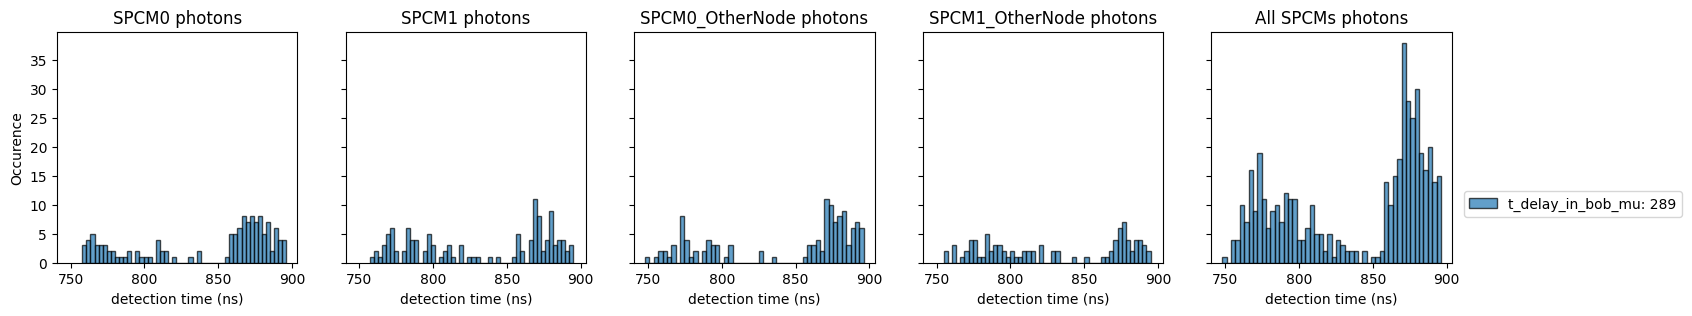

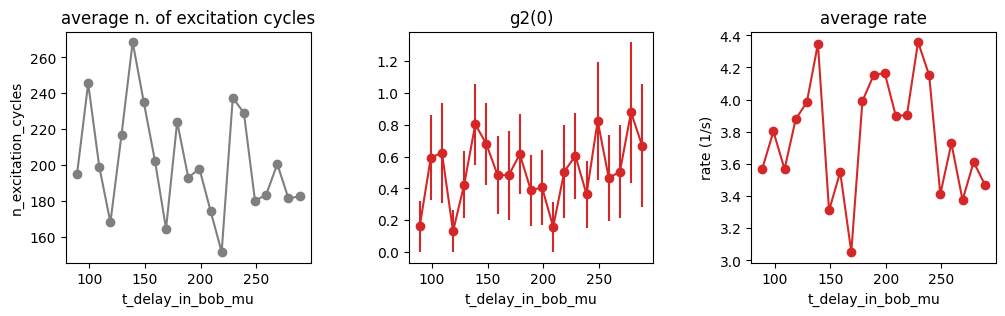

In [37]:
"""
What each variable represents. Example values are mostly from RID 22496, 2025-02-26. Variables ending in _iAll contain data for all interations with length equal to "iterations".

n_measurements = 2000: directly from dataset
iterations = 5: the length of scan_sequence1, directly from dataset
n_excitation_cycles = [0,  2, 20,  8,  2,  8, ...], length = 1 + n_measurements * iterations: the number of excitation cycles in each measurement
n_excitation_cycles_iAll = [16830, 16665, 16488, 16194, 16221], length = iterations: total number of excitation cycles in each iteration as an array.
n_excitation_attempts = 1: directly from dataset. Number of excitation pulses in each excitation cycle.
n_tStamps_iAll = [16830, 16665, 16488, 16194, 16221], length = iterations: total number of timestamps in each iteration as an array.
SPCM0_Photon_tStamps = [[0, 0], [-1, -1], [-1, -1], [1.32237714e+06, -1], [-1, -1], ...], length = sum(n_tStamps_iAll) = 82399, for example. Directly from dataset.
SPCM0_tStamps_i =  [[-1, -1], [-1, -1], [1.32237714e+06, -1], [-1, -1], ...], length = elements of n_tStamps_iAll, 16830 for the first iteration, for example. The timestamps in each iteration.
reference_tStamps_t1 = [0, 1322341.65973562, 1322341.65976682, 1322341.65979802, ...], length = sum(n_tStamps_iAll) = 82399, for example. Directly from dataset.
t1_reference_i = [1322341.65973562, 1322341.65976682, 1322341.65979802, ...], length = elements of n_tStamps_iAll, 16830 for the first iteration, for example. The reference times in each iteration.
SPCM0_1click_counts_iAll = [128., 122., 172., 186., 172.], length = iterations: number of 1-click events in each iteration as an array; events in the first column of SPCM0_tStamps_i for different iteration.
SPCM0_2click_counts_iAll = [0., 0., 0., 0., 0.], length = iterations: number of 2-click events in each iteration as an array; events in the second column of SPCM0_tStamps_i for different iteration.
start_indices = [0, 16830, 33495, 49983, 66177], length = iterations: to slice arrays like SPCM0_Photon_tStamps into iterations.
    Remember that SPCM0_Photon_tStamps is a single array with the timestamps for all iterations.
end_indices = [16830, 33495, 49983, 66177, 82398], length = iterations: same as start_indices
SPCM0_rel_tStamps_i = [1099.89196062, 1088.94892037, 1098.02931547, ...], length = SPCM0_1click_counts_iAll + SPCM0_2click_counts_iAll, for example length is 128 and 122 for first two iterations.
    This array contains the timestamps relative to the reference time t1 in ns unit. -1 event are excluded and 2-click events are included.
SPCM0_rel_tStamps_iAll = [[1099.89196062, 1088.94892037, 1098.02931547, ...], [..], ..], length = iterations. Arrays of arrays containing all the relative timestamps for all iteration.
AllSPCMs_tStamps_filtered_i = [[1757511.19383094, 1757533.11171639, ...], length = total number of photons in iteration i,
    i.e. length = all 1-click and 2-click counts from SPCM0, SPCM1, SPCM0_OtherNode, and SPCM1_OtherNode. Contains all the absolute time stamps from all 4 SPCMs with -1 removed and sorted from small to large.
AllSPCMs_tStamps_filtered_iAll = [[1757511.19383094, 1757533.11171639, ...], [1749316.29104084, 1749328.33163165, ..], ..], length = iterations. Array of arrays keeping all
    AllSPCMs_tStamps_filtered_i from all iterations.
Ave_photon_rate_iAll = [[0.11084697, 0.1147433 , 0.10952382, 0.1337287 , 0.12123424]], length = iterations. Contains the average photon generation rate for all iterations.
n_coincidence_iAll = [0,0,1,0,2], length = iterations. The number of coincidences in each iteration used to calculate g2.

Other notes:
1- Does this work if I change max_clicks from 2 to 1 or 3? The answer is no.

"""

### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))

Col_Eff = 0.05 # overal expected/theoretical collection and detection efficiency

### Instead of using a large n_measurements, which can sometimes lead to underflow error, we use dummy_variable to split the measurements.
### So, if scan_variable1_name == 'dummy_variable', we want to combine all iterations into one:
if scan_variable1_name == 'dummy_variable':
    n_measurements = n_measurements * iterations
    iterations = 1
    scan_sequence1 = [0]

## To look at specific iterations, you can select in scan_sequence_1, for example scan_sequence1 = [0,2]. For now, the first element has to be 0.
# scan_sequence1 = [0,4]
# iterations = len(scan_sequence1)
# n_measurements = n_measurements * iterations


n_excitation_cycles_iAll = np.zeros(iterations, dtype=int) ### total number of excitation cycle in each iteration.
n_tStamps_iAll = np.zeros(iterations, dtype=int)  ### number of timestamps in each iteration.
for i in range(iterations):
    n_excitation_cycles_iAll[i] = sum(n_excitation_cycles[i*n_measurements+1:(i+1)*n_measurements+1]+1)
    if scan_variable1_name == 'n_excitation_attempts':
        n_excitation_attempts = scan_sequence1[i]
    n_tStamps_iAll[i] = n_excitation_cycles_iAll[i] * n_excitation_attempts
    ### Note that n_excitation_cycles varies in each cycle, each contains n_excitation_attempts.
    ### the first +1 is because the first element in each dataset is 0.
    ### the last +1 is because there is one more cycle than n_excitation_cycles in each loop. See the oscciloscope. For example, if n_excitation_cycles[j] = 2,
    ### there are 2+1=3 sets of excitation cycles for that measurement.


SPCM0_1click_counts_iAll = np.array([])
SPCM0_2click_counts_iAll = np.array([])
SPCM1_1click_counts_iAll = np.array([])
SPCM1_2click_counts_iAll = np.array([])
SPCM0_OtherNode_1click_counts_iAll = np.array([])
SPCM0_OtherNode_2click_counts_iAll = np.array([])
SPCM1_OtherNode_1click_counts_iAll = np.array([])
SPCM1_OtherNode_2click_counts_iAll = np.array([])

AllSPCMs_tStamps_filtered_iAll = []

SPCM0_rel_tStamps_iAll = []
SPCM1_rel_tStamps_iAll = []
SPCM0_OtherNode_rel_tStamps_iAll = []
SPCM1_OtherNode_rel_tStamps_iAll = []

n_coincidence_iAll = np.zeros(iterations)
g2_0 = np.zeros(iterations)
g2_0_err = np.zeros(iterations)
Ave_photon_rate_iAll = np.zeros(iterations)


def get_rel_tStamps_i(tStamps_i, t1_reference_i, spcm_name):
    ### the timestamps relative to reference time. -1 events are excluded.
    rel_tStamps_i_temp = [row[row != -1] - ref for row, ref in zip(tStamps_i, t1_reference_i)]
    if not rel_tStamps_i_temp: ### np.concatenate crashes on empty lists; if no photon detected, I replace timetags by [0].
        rel_tStamps_i_temp = [[0]]
    rel_tStamps_i_temp2 = np.concatenate(rel_tStamps_i_temp) * 1e9 ## Flatten to combine 1-click and 2-click events.
    rel_tStamps_i = rel_tStamps_i_temp2[rel_tStamps_i_temp2 >= 0]
    ## in 1 out of 1million case, the reference time is later than the timetag and I get a negative
    ### element which messes up the histograms. I am simply removing these elements if any, and printing
    if len(rel_tStamps_i) != len(rel_tStamps_i_temp2):
        print(f'Early time stamp for {len(rel_tStamps_i_temp2) - len(rel_tStamps_i)} elements on {spcm_name} was detected.')
    return rel_tStamps_i


def get_tStamps_i(tStamps_all, start, end):
    tStamps_i = np.asarray(tStamps_all[1:][start:end])
    if tStamps_i.size == 0:
        return np.empty((0, 2))
    if tStamps_i.ndim == 1:
        return tStamps_i.reshape(-1, 2)
    return tStamps_i


### Calculate the ending and starting indices for the iterations
end_indices = np.cumsum(n_tStamps_iAll)
start_indices = np.insert(end_indices[:-1], 0, 0) ### prepend a 0 for the starting index

for i in range(iterations):
    start = start_indices[i]
    end = end_indices[i]
    SPCM0_tStamps_i = get_tStamps_i(SPCM0_Photon_tStamps, start, end)
    SPCM1_tStamps_i = get_tStamps_i(SPCM1_Photon_tStamps, start, end)
    SPCM0_OtherNode_tStamps_i = get_tStamps_i(SPCM0_OtherNode_Photon_tStamps, start, end)
    SPCM1_OtherNode_tStamps_i = get_tStamps_i(SPCM1_OtherNode_Photon_tStamps, start, end)
    t1_reference_i = reference_tStamps_t1[1:][start:end]

    ### number of 1-click events (the first column is none -1)
    SPCM0_1click_counts_iAll = np.append(SPCM0_1click_counts_iAll, np.count_nonzero(SPCM0_tStamps_i[:, 0] != -1))
    SPCM1_1click_counts_iAll = np.append(SPCM1_1click_counts_iAll, np.count_nonzero(SPCM1_tStamps_i[:, 0] != -1))
    SPCM0_OtherNode_1click_counts_iAll = np.append(SPCM0_OtherNode_1click_counts_iAll, np.count_nonzero(SPCM0_OtherNode_tStamps_i[:, 0] != -1))
    SPCM1_OtherNode_1click_counts_iAll = np.append(SPCM1_OtherNode_1click_counts_iAll, np.count_nonzero(SPCM1_OtherNode_tStamps_i[:, 0] != -1))

    ### number of 2-click events (the 2nd column is none -1)
    SPCM0_2click_counts_iAll = np.append(SPCM0_2click_counts_iAll, np.count_nonzero(SPCM0_tStamps_i[:, 1] != -1))
    SPCM1_2click_counts_iAll = np.append(SPCM1_2click_counts_iAll, np.count_nonzero(SPCM1_tStamps_i[:, 1] != -1))
    SPCM0_OtherNode_2click_counts_iAll = np.append(SPCM0_OtherNode_2click_counts_iAll, np.count_nonzero(SPCM0_OtherNode_tStamps_i[:, 1] != -1))
    SPCM1_OtherNode_2click_counts_iAll = np.append(SPCM1_OtherNode_2click_counts_iAll, np.count_nonzero(SPCM1_OtherNode_tStamps_i[:, 1] != -1))

    SPCM0_rel_tStamps_i = get_rel_tStamps_i(SPCM0_tStamps_i, t1_reference_i, 'SPCM0')
    SPCM1_rel_tStamps_i = get_rel_tStamps_i(SPCM1_tStamps_i, t1_reference_i, 'SPCM1')
    SPCM0_OtherNode_rel_tStamps_i = get_rel_tStamps_i(SPCM0_OtherNode_tStamps_i, t1_reference_i, 'SPCM0_OtherNode')
    SPCM1_OtherNode_rel_tStamps_i = get_rel_tStamps_i(SPCM1_OtherNode_tStamps_i, t1_reference_i, 'SPCM1_OtherNode')

    SPCM0_rel_tStamps_iAll.append(SPCM0_rel_tStamps_i)
    SPCM1_rel_tStamps_iAll.append(SPCM1_rel_tStamps_i)
    SPCM0_OtherNode_rel_tStamps_iAll.append(SPCM0_OtherNode_rel_tStamps_i)
    SPCM1_OtherNode_rel_tStamps_iAll.append(SPCM1_OtherNode_rel_tStamps_i)

    ### calculate g2 for each iteration. In future, we can also select a narrower coincidence window.
    ### For 4 SPCMs, count coincidences between all unordered detector pairs.
    first_click_arrays_i = [
        SPCM0_tStamps_i[:, 0],
        SPCM1_tStamps_i[:, 0],
        SPCM0_OtherNode_tStamps_i[:, 0],
        SPCM1_OtherNode_tStamps_i[:, 0],
    ]
    first_click_counts_i = [
        SPCM0_1click_counts_iAll[i],
        SPCM1_1click_counts_iAll[i],
        SPCM0_OtherNode_1click_counts_iAll[i],
        SPCM1_OtherNode_1click_counts_iAll[i],
    ]

    n_coincidence_i = 0
    g2_denominator_i = 0
    g2_denominator_var_i = 0
    for j in range(len(first_click_arrays_i)):
        for k in range(j + 1, len(first_click_arrays_i)):
            n_coincidence_i += np.sum((first_click_arrays_i[j] >= 1) & (first_click_arrays_i[k] >= 1))

            Nj = first_click_counts_i[j]
            Nk = first_click_counts_i[k]
            g2_denominator_i += Nj * Nk
            g2_denominator_var_i += (Nk**2) * Nj + (Nj**2) * Nk

    # n_coincidence_i = 1 ### if there is no coincidence, you can set n_coincidence_i = 1 manually to find the bound to g2 because the next count might be a coincidence.
    n_coincidence_iAll[i] = n_coincidence_i ### Having a list of coincidences for each iteration helps to learn more about the g2.

    if g2_denominator_i > 0:
        g2_0_temp = (n_coincidence_i / g2_denominator_i) * n_excitation_cycles_iAll[i]
        ### Errors for g2 results are from error propagation assuming Poissonian distribution for counts:
        if n_coincidence_i > 0:
            g2_0_err_temp = g2_0_temp * np.sqrt(1/n_coincidence_i + g2_denominator_var_i/(g2_denominator_i**2))
        else:
            g2_0_err_temp = np.nan
    else:
        g2_0_temp = np.nan
        g2_0_err_temp = np.nan
    g2_0[i] = g2_0_temp
    g2_0_err[i] = g2_0_err_temp

    ############## absolute timestamps of all the photons for rate analysis
    AllSPCMs_tStamps_flatten_i = np.concatenate((
        SPCM0_tStamps_i,
        SPCM1_tStamps_i,
        SPCM0_OtherNode_tStamps_i,
        SPCM1_OtherNode_tStamps_i,
    )).flatten() ### flatten to get the timestamps of all photons (1st and 2nd clicks).
    AllSPCMs_tStamps_filtered_i = AllSPCMs_tStamps_flatten_i[AllSPCMs_tStamps_flatten_i != -1]  ### -1 events are removed
    AllSPCMs_tStamps_filtered_i = np.sort(AllSPCMs_tStamps_filtered_i) ### sorted from small to large timestamps
    AllSPCMs_tStamps_filtered_iAll.append(AllSPCMs_tStamps_filtered_i)


    # ###########checking H1H2 ###############
    # count=0
    # for j in range(len(SPCM0_tStamps_i)):
    #     if SPCM0_tStamps_i[:, 0][j] != -1 and SPCM0_OtherNode_tStamps_i[:, 0][j] != -1:
    #         count+=1
    
    # print("H1H2 ", count)
    # ###########checking V1V2 ###############
    # count=0
    # for j in range(len(SPCM1_tStamps_i)):
    #     if SPCM1_tStamps_i[:, 0][j] != -1 and SPCM1_OtherNode_tStamps_i[:, 0][j] != -1:
    #         count+=1
    
    # print("V1V2 ",count)
    
    # ###########checking (H1orV1) (H2orV2) ###############
    # count=0
    # for j in range(len(SPCM1_tStamps_i)):
    #     if (SPCM0_tStamps_i[:, 0][j] != -1 or SPCM1_tStamps_i[:, 0][j] != -1) and (SPCM0_OtherNode_tStamps_i[:, 0][j] != -1 or SPCM1_OtherNode_tStamps_i[:, 0][j] != -1):
    #         count+=1
    
    # print("(H1orV1) (H2orV2) ",count)
    


AllSPCMs_1click_counts_iAll = (
    SPCM0_1click_counts_iAll
    + SPCM1_1click_counts_iAll
    + SPCM0_OtherNode_1click_counts_iAll
    + SPCM1_OtherNode_1click_counts_iAll
)
AllSPCMs_2click_counts_iAll = (
    SPCM0_2click_counts_iAll
    + SPCM1_2click_counts_iAll
    + SPCM0_OtherNode_2click_counts_iAll
    + SPCM1_OtherNode_2click_counts_iAll
)


print(f'n_measurements = {n_measurements}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}','ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')
print(f'excitation AOM power (dBm) = {p_excitation}')
print(f'n_excitation_attempts = {n_excitation_attempts}')
print(f'check atom avery n excitation cycles = {atom_check_every_n}')
if n_excitation_cycles_iAll[0] > 0:
    print(f'Overal photon detection efficiency (%) = {100*AllSPCMs_1click_counts_iAll[0]/n_excitation_cycles_iAll[0]}')
else:
    print('Overal photon detection efficiency (%) = nan')



#############  Average photon generation rate calculated from last timestamp minus first timestamp.
for i in range(iterations):
    if len(AllSPCMs_tStamps_filtered_iAll[i]) >= 2:
        t_duration_i = max(AllSPCMs_tStamps_filtered_iAll[i]) - min(AllSPCMs_tStamps_filtered_iAll[i])
        if t_duration_i > 0:
            Ave_photon_rate_iAll[i] = (AllSPCMs_1click_counts_iAll[i] + AllSPCMs_2click_counts_iAll[i]) / t_duration_i
        else:
            Ave_photon_rate_iAll[i] = np.nan
    else:
        Ave_photon_rate_iAll[i] = np.nan


###################################################### plot of 1-click and 2-click counts
fig, axs = plt.subplots(1, 5, figsize=(18, 3), sharey=True)

### SPCM0
axs[0].plot(scan_sequence1, SPCM0_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[0].plot(scan_sequence1, SPCM0_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[0].errorbar(scan_sequence1, SPCM0_1click_counts_iAll, yerr=np.sqrt(SPCM0_1click_counts_iAll), ls='none', color='tab:red')
axs[0].errorbar(scan_sequence1, SPCM0_2click_counts_iAll, yerr=np.sqrt(SPCM0_2click_counts_iAll), ls='none', color='tab:blue')
axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name);

### SPCM1
axs[1].plot(scan_sequence1, SPCM1_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[1].plot(scan_sequence1, SPCM1_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[1].errorbar(scan_sequence1, SPCM1_1click_counts_iAll, yerr=np.sqrt(SPCM1_1click_counts_iAll), ls='none', color='tab:red')
axs[1].errorbar(scan_sequence1, SPCM1_2click_counts_iAll, yerr=np.sqrt(SPCM1_2click_counts_iAll), ls='none', color='tab:blue')
axs[1].set_title('SPCM1')
axs[1].set_ylabel('Occurrences')
axs[1].set_xlabel(scan_variable1_name);

### SPCM0_OtherNode
axs[2].plot(scan_sequence1, SPCM0_OtherNode_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[2].plot(scan_sequence1, SPCM0_OtherNode_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[2].errorbar(scan_sequence1, SPCM0_OtherNode_1click_counts_iAll, yerr=np.sqrt(SPCM0_OtherNode_1click_counts_iAll), ls='none', color='tab:red')
axs[2].errorbar(scan_sequence1, SPCM0_OtherNode_2click_counts_iAll, yerr=np.sqrt(SPCM0_OtherNode_2click_counts_iAll), ls='none', color='tab:blue')
axs[2].set_title('SPCM0_OtherNode')
axs[2].set_ylabel('Occurrences')
axs[2].set_xlabel(scan_variable1_name);

### SPCM1_OtherNode
axs[3].plot(scan_sequence1, SPCM1_OtherNode_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[3].plot(scan_sequence1, SPCM1_OtherNode_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[3].errorbar(scan_sequence1, SPCM1_OtherNode_1click_counts_iAll, yerr=np.sqrt(SPCM1_OtherNode_1click_counts_iAll), ls='none', color='tab:red')
axs[3].errorbar(scan_sequence1, SPCM1_OtherNode_2click_counts_iAll, yerr=np.sqrt(SPCM1_OtherNode_2click_counts_iAll), ls='none', color='tab:blue')
axs[3].set_title('SPCM1_OtherNode')
axs[3].set_ylabel('Occurrences')
axs[3].set_xlabel(scan_variable1_name);

### all SPCMs
axs[4].plot(scan_sequence1, n_excitation_cycles_iAll * Col_Eff, label='Max expected', ls='solid', color='tab:gray', marker='o') ### I assumed only one excitation can happen with n_excitation_attempts
axs[4].plot(scan_sequence1, AllSPCMs_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[4].plot(scan_sequence1, AllSPCMs_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[4].errorbar(scan_sequence1, AllSPCMs_1click_counts_iAll, yerr=np.sqrt(AllSPCMs_1click_counts_iAll), ls='none', color='tab:red')
axs[4].errorbar(scan_sequence1, AllSPCMs_2click_counts_iAll, yerr=np.sqrt(AllSPCMs_2click_counts_iAll), ls='none', color='tab:blue')
axs[4].set_title('All SPCMs')
axs[4].set_ylabel('Occurrences')
axs[4].set_xlabel(scan_variable1_name);
axs[4].legend(loc=(1.05,0.2))
##########################################################################################




###################################################### plot of 2-click counts
fig, axs = plt.subplots(1, 5, figsize=(18, 3), sharey=True)

### SPCM0
# axs[0].plot(scan_sequence1, SPCM0_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[0].plot(scan_sequence1, SPCM0_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[0].errorbar(scan_sequence1, SPCM0_1click_counts_iAll, yerr=np.sqrt(SPCM0_1click_counts_iAll), ls='none', color='tab:red')
axs[0].errorbar(scan_sequence1, SPCM0_2click_counts_iAll, yerr=np.sqrt(SPCM0_2click_counts_iAll), ls='none', color='tab:blue')
axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name);

### SPCM1
# axs[1].plot(scan_sequence1, SPCM1_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[1].plot(scan_sequence1, SPCM1_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[1].errorbar(scan_sequence1, SPCM1_1click_counts_iAll, yerr=np.sqrt(SPCM1_1click_counts_iAll), ls='none', color='tab:red')
axs[1].errorbar(scan_sequence1, SPCM1_2click_counts_iAll, yerr=np.sqrt(SPCM1_2click_counts_iAll), ls='none', color='tab:blue')
axs[1].set_title('SPCM1')
axs[1].set_ylabel('Occurrences')
axs[1].set_xlabel(scan_variable1_name);

### SPCM0_OtherNode
# axs[2].plot(scan_sequence1, SPCM0_OtherNode_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[2].plot(scan_sequence1, SPCM0_OtherNode_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[2].errorbar(scan_sequence1, SPCM0_OtherNode_1click_counts_iAll, yerr=np.sqrt(SPCM0_OtherNode_1click_counts_iAll), ls='none', color='tab:red')
axs[2].errorbar(scan_sequence1, SPCM0_OtherNode_2click_counts_iAll, yerr=np.sqrt(SPCM0_OtherNode_2click_counts_iAll), ls='none', color='tab:blue')
axs[2].set_title('SPCM0_OtherNode')
axs[2].set_ylabel('Occurrences')
axs[2].set_xlabel(scan_variable1_name);

### SPCM1_OtherNode
# axs[3].plot(scan_sequence1, SPCM1_OtherNode_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[3].plot(scan_sequence1, SPCM1_OtherNode_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[3].errorbar(scan_sequence1, SPCM1_OtherNode_1click_counts_iAll, yerr=np.sqrt(SPCM1_OtherNode_1click_counts_iAll), ls='none', color='tab:red')
axs[3].errorbar(scan_sequence1, SPCM1_OtherNode_2click_counts_iAll, yerr=np.sqrt(SPCM1_OtherNode_2click_counts_iAll), ls='none', color='tab:blue')
axs[3].set_title('SPCM1_OtherNode')
axs[3].set_ylabel('Occurrences')
axs[3].set_xlabel(scan_variable1_name);

### all SPCMs
# axs[4].plot(scan_sequence1, n_excitation_cycles_iAll * Col_Eff, label='Max expected', ls='solid', color='tab:gray', marker='o') ### I assumed only one excitation can happen with n_excitation_attempts
# axs[4].plot(scan_sequence1, AllSPCMs_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[4].plot(scan_sequence1, AllSPCMs_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[4].errorbar(scan_sequence1, AllSPCMs_1click_counts_iAll, yerr=np.sqrt(AllSPCMs_1click_counts_iAll), ls='none', color='tab:red')
axs[4].errorbar(scan_sequence1, AllSPCMs_2click_counts_iAll, yerr=np.sqrt(AllSPCMs_2click_counts_iAll), ls='none', color='tab:blue')
axs[4].set_title('All SPCMs')
axs[4].set_ylabel('Occurrences')
axs[4].set_xlabel(scan_variable1_name);
axs[4].legend(loc=(1.05,0.2))
##########################################################################################


AllSPCMs_rel_tStamps_iAll = [
    np.concatenate((spcm0, spcm1, spcm0_other, spcm1_other))
    for spcm0, spcm1, spcm0_other, spcm1_other in zip(
        SPCM0_rel_tStamps_iAll,
        SPCM1_rel_tStamps_iAll,
        SPCM0_OtherNode_rel_tStamps_iAll,
        SPCM1_OtherNode_rel_tStamps_iAll,
    )
]

###################################################### plot of photon histograms
for i in range(iterations):
    fig, axs = plt.subplots(1, 5, figsize=(18, 3), sharey=True, sharex=True)

    axs[0].hist(SPCM0_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7)
    axs[0].set_xlabel("detection time (ns)")
    axs[0].set_ylabel("Occurence")
    axs[0].set_title("SPCM0 photons")

    axs[1].hist(SPCM1_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7)
    axs[1].set_xlabel("detection time (ns)")
    axs[1].set_title("SPCM1 photons");

    axs[2].hist(SPCM0_OtherNode_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7)
    axs[2].set_xlabel("detection time (ns)")
    axs[2].set_title("SPCM0_OtherNode photons")

    axs[3].hist(SPCM1_OtherNode_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7)
    axs[3].set_xlabel("detection time (ns)")
    axs[3].set_title("SPCM1_OtherNode photons");

    axs[4].hist(AllSPCMs_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7, label=f'{scan_variable1_name}: {scan_sequence1[i]}')
    axs[4].set_xlabel("detection time (ns)")
    axs[4].set_title("All SPCMs photons")
    axs[4].legend(loc=(1.05, 0.2))
##########################################################################################


fig, axs = plt.subplots(1, 3, figsize=(12, 3))
########################################## Plot average number of excitation_cycles per measuremnt
axs[0].plot(scan_sequence1, n_excitation_cycles_iAll/n_measurements, label='ave excitation cycle', marker='o', color='tab:gray')
axs[0].set_xlabel(scan_variable1_name)
axs[0].set_ylabel('n_excitation_cycles')
axs[0].set_title('average n. of excitation cycles')

########################################## Plot g2
axs[1].plot(scan_sequence1, g2_0, marker='o', color='tab:red')
axs[1].errorbar(scan_sequence1, g2_0, yerr=g2_0_err, ls='none',color='tab:red')
axs[1].set_xlabel(scan_variable1_name)
# axs[1].set_ylabel('g2(0)')
axs[1].set_title('g2(0)');

########################################## Plot avergae rate
axs[2].plot(scan_sequence1, Ave_photon_rate_iAll, marker='o', color='tab:red')
# axs[2].legend(loc=(1.05,0.5))
axs[2].set_xlabel(scan_variable1_name)
axs[2].set_ylabel('rate (1/s)')
axs[2].set_title('average rate');

plt.subplots_adjust(wspace=0.4)  # Increase spacing between subplots
plt.show()


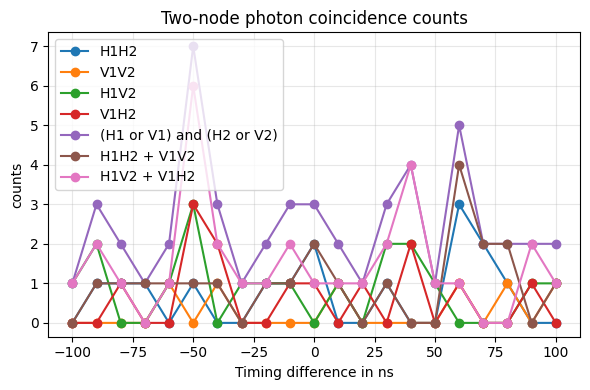

In [40]:
H1H2_clicks_iAll = np.array([])
V1V2_clicks_iAll = np.array([])
H1V2_clicks_iAll = np.array([])
V1H2_clicks_iAll = np.array([])

H1orV1_and_H2orV2_clicks_iAll = np.array([])

H1H2_or_V1V2_clicks_iAll = np.array([])
H1V2_or_V1H2_clicks_iAll = np.array([])

for i in range(iterations):
    start = start_indices[i]
    end = end_indices[i]

    SPCM0_tStamps_i = get_tStamps_i(SPCM0_Photon_tStamps, start, end)                  # H1
    SPCM1_tStamps_i = get_tStamps_i(SPCM1_Photon_tStamps, start, end)                  # V1
    SPCM0_OtherNode_tStamps_i = get_tStamps_i(SPCM0_OtherNode_Photon_tStamps, start, end)  # H2
    SPCM1_OtherNode_tStamps_i = get_tStamps_i(SPCM1_OtherNode_Photon_tStamps, start, end)  # V2
    t1_reference_i = reference_tStamps_t1[1:][start:end]

    ########### checking H1H2 ###############
    count = 0
    for j in range(len(SPCM0_tStamps_i)):
        if SPCM0_tStamps_i[:, 0][j] != -1 and SPCM0_OtherNode_tStamps_i[:, 0][j] != -1:
            count += 1
    H1H2_clicks_iAll = np.append(H1H2_clicks_iAll, count)

    ########### checking V1V2 ###############
    count = 0
    for j in range(len(SPCM1_tStamps_i)):
        if SPCM1_tStamps_i[:, 0][j] != -1 and SPCM1_OtherNode_tStamps_i[:, 0][j] != -1:
            count += 1
    V1V2_clicks_iAll = np.append(V1V2_clicks_iAll, count)

    ########### checking H1V2 ###############
    count = 0
    for j in range(len(SPCM0_tStamps_i)):
        if SPCM0_tStamps_i[:, 0][j] != -1 and SPCM1_OtherNode_tStamps_i[:, 0][j] != -1:
            count += 1
    H1V2_clicks_iAll = np.append(H1V2_clicks_iAll, count)

    ########### checking V1H2 ###############
    count = 0
    for j in range(len(SPCM1_tStamps_i)):
        if SPCM1_tStamps_i[:, 0][j] != -1 and SPCM0_OtherNode_tStamps_i[:, 0][j] != -1:
            count += 1
    V1H2_clicks_iAll = np.append(V1H2_clicks_iAll, count)

    ########### checking (H1 or V1) and (H2 or V2) ###############
    count = 0
    for j in range(len(SPCM1_tStamps_i)):
        if (SPCM0_tStamps_i[:, 0][j] != -1 or SPCM1_tStamps_i[:, 0][j] != -1) and \
           (SPCM0_OtherNode_tStamps_i[:, 0][j] != -1 or SPCM1_OtherNode_tStamps_i[:, 0][j] != -1):
            count += 1
    H1orV1_and_H2orV2_clicks_iAll = np.append(H1orV1_and_H2orV2_clicks_iAll, count)

    H1H2_or_V1V2_clicks_iAll = H1H2_clicks_iAll + V1V2_clicks_iAll
    H1V2_or_V1H2_clicks_iAll = H1V2_clicks_iAll + V1H2_clicks_iAll


x_scan = np.asarray(scan_sequence1) - 189

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(x_scan, H1H2_clicks_iAll, label='H1H2', marker='o')
ax.plot(x_scan, V1V2_clicks_iAll, label='V1V2', marker='o')
ax.plot(x_scan, H1V2_clicks_iAll, label='H1V2', marker='o')
ax.plot(x_scan, V1H2_clicks_iAll, label='V1H2', marker='o')
ax.plot(x_scan, H1orV1_and_H2orV2_clicks_iAll, label='(H1 or V1) and (H2 or V2)', marker='o')
ax.plot(x_scan, H1H2_or_V1V2_clicks_iAll, label='H1H2 + V1V2', marker='o')
ax.plot(x_scan, H1V2_or_V1H2_clicks_iAll, label='H1V2 + V1H2', marker='o')

ax.set_xlabel(f"Timing difference in ns")
ax.set_ylabel('counts')
ax.set_title('Two-node photon coincidence counts')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

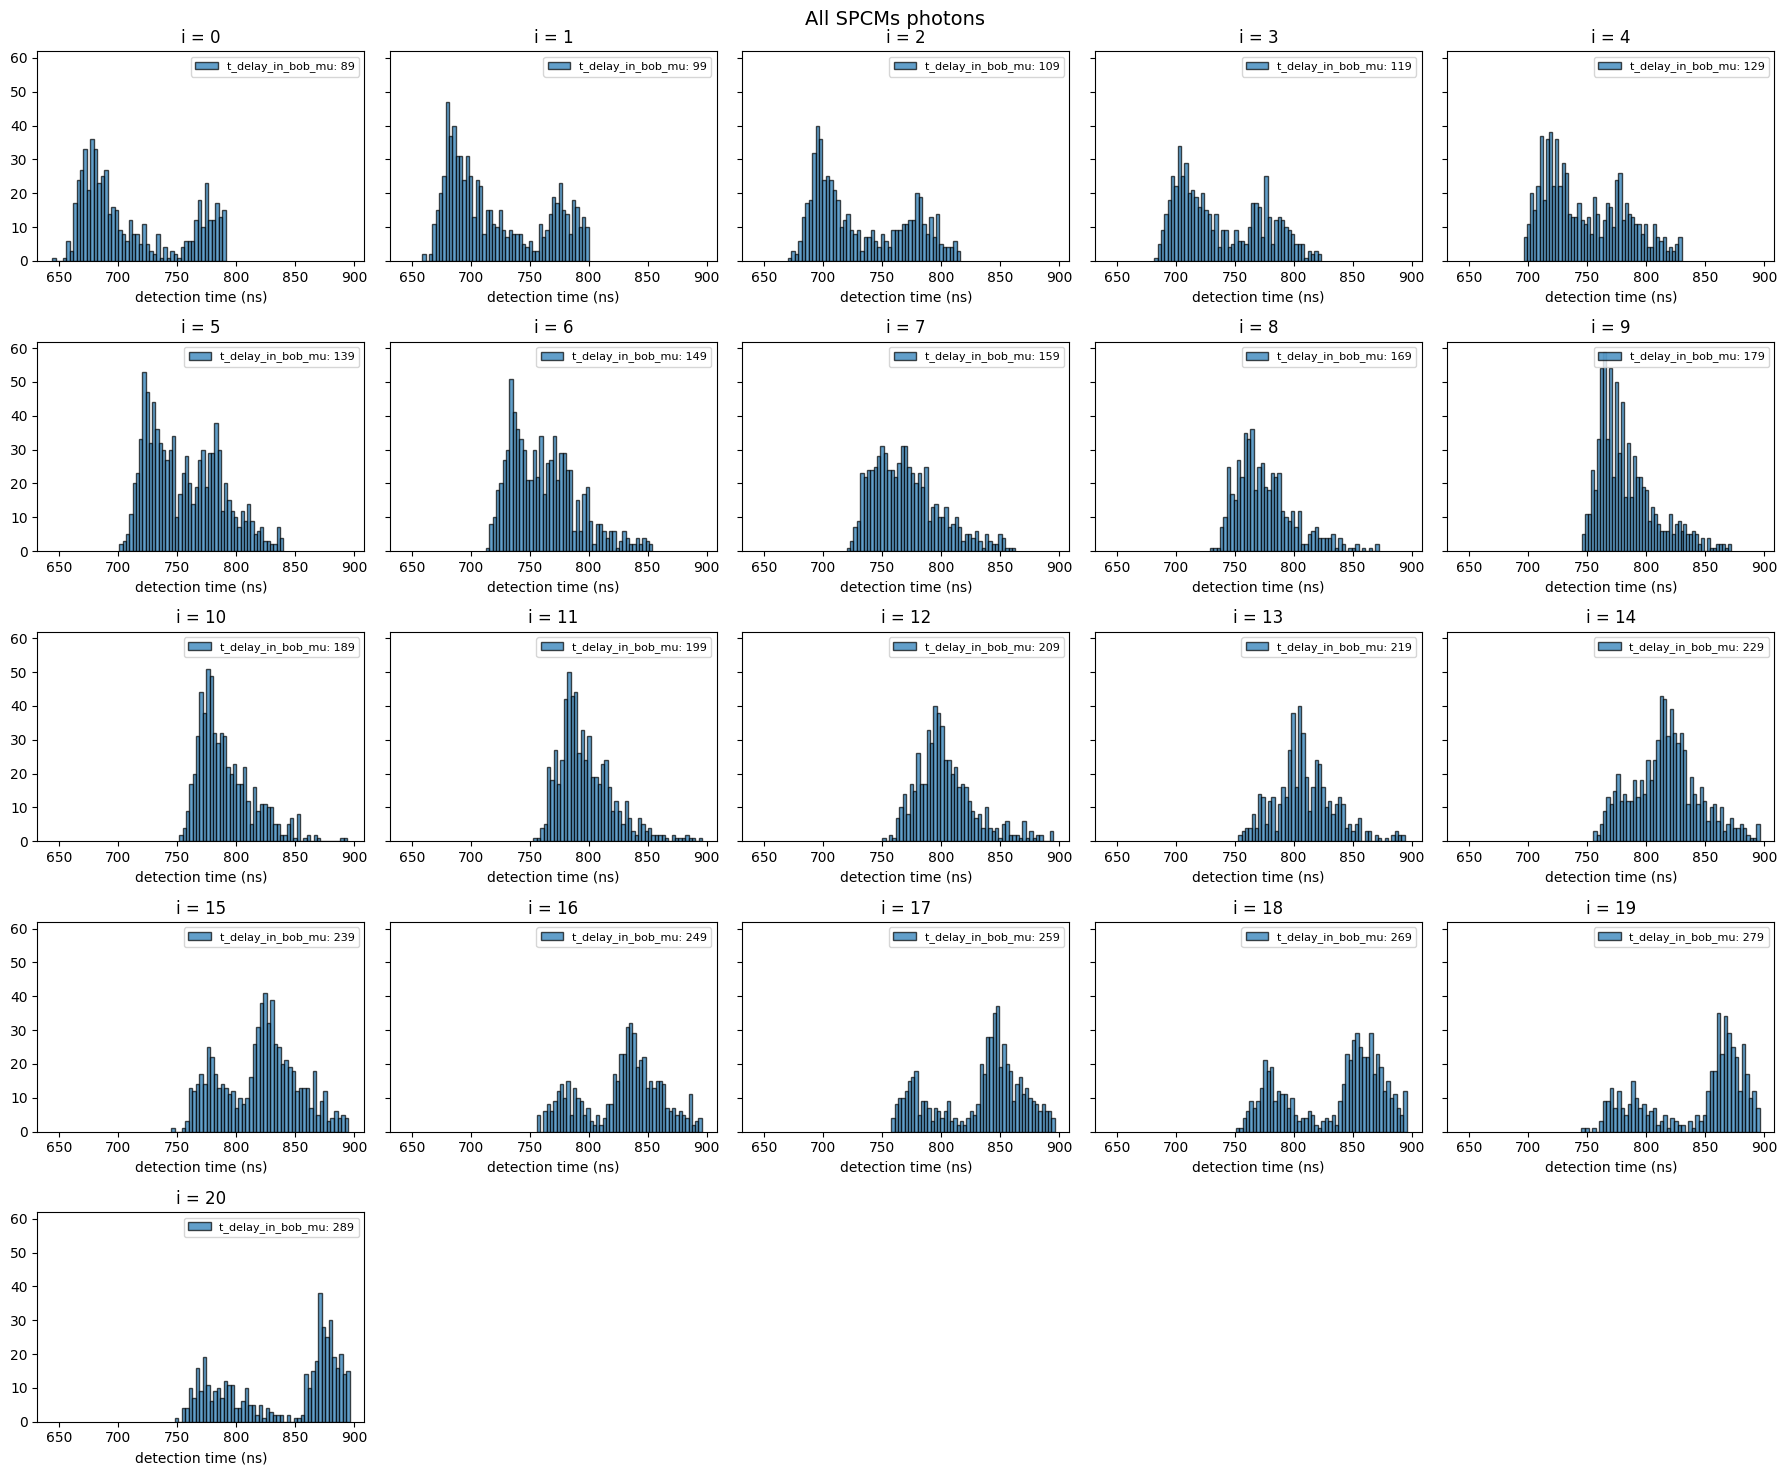

In [42]:
###################################################### plot of photon histograms

ncols = 5
nrows = int(np.ceil(iterations / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(18, 3*nrows), sharey=True, sharex=True)
axs = np.ravel(axs)

for i in range(iterations):
    axs[i].hist(
        AllSPCMs_rel_tStamps_iAll[i],
        bins=50,
        edgecolor='black',
        alpha=0.7,
        label=f'{scan_variable1_name}: {scan_sequence1[i]}'
    )

    axs[i].set_xlabel("detection time (ns)")
    axs[i].set_title(f"i = {i}")
    axs[i].legend(fontsize=8)

    # show x-axis detection time ticks on every subplot
    axs[i].tick_params(axis='x', labelbottom=True)

# Hide unused empty subplots
for j in range(iterations, len(axs)):
    axs[j].axis("off")

fig.suptitle("All SPCMs photons", fontsize=14)
plt.tight_layout()
plt.show()